In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Loading dataset from Hugging Face
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup

# Convert the date column to a proper datetime format so we can analyze trend over time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Convert the text strings in the skills column into actual Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# Filter for US Data Analyst jobs
df_US = df[(df["job_country"] == "United States")].copy()

# Drop missing salaries just for this notebook
df_US = df_US.dropna(subset=["salary_year_avg"])

In [3]:
# Text Standardization: Creating a 'job_level' column based on job_title keywords
def assign_seniority(title):
    title = str(title).lower()
    if any(
        word in title for word in ["sr", "senior", "lead", "principal", "ii", "iii"]
    ):
        return "Senior"
    elif any(word in title for word in ["jr", "junior", "entry", "intern", "i"]):
        return "Junior"
    else:
        return "Mid-Level / Unspecified"


df_US["job_level"] = df_US["job_title"].apply(assign_seniority)


In [4]:
# To find the top 6 most common data roles.

# showing all job_titles as list
job_titles = df_US["job_title_short"].value_counts().index[:6].tolist()
print(job_titles)

df_US_Top6 = df_US[df_US["job_title_short"].isin(job_titles)]
job_ordered = (
    df_US_Top6.groupby("job_title_short")["salary_year_avg"]
    .median()
    .sort_values(ascending=False)
    .index
)

['Data Scientist', 'Data Analyst', 'Data Engineer', 'Senior Data Scientist', 'Senior Data Engineer', 'Senior Data Analyst']


C:\Users\HP\AppData\Local\Temp\ipykernel_6388\2857185971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


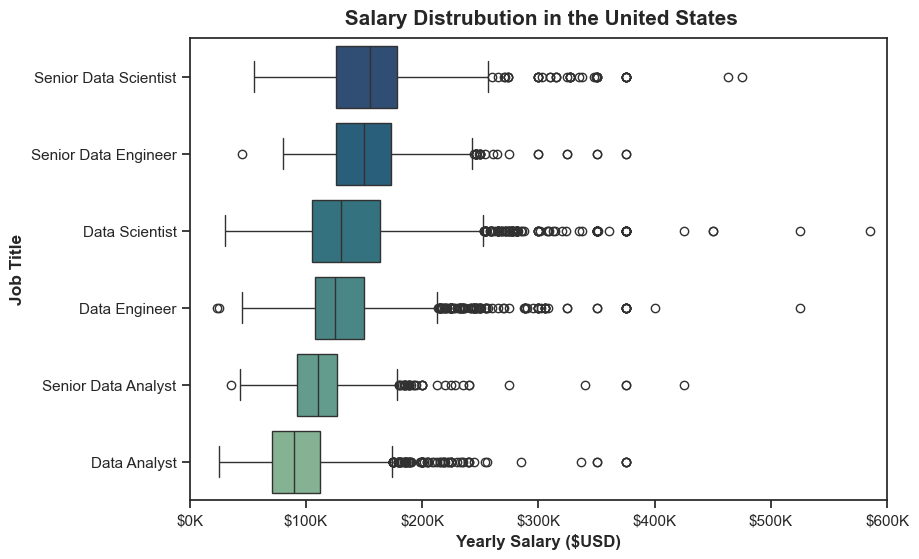

In [29]:
# use a boxplot here (intentionally keeping the extreme outliers) 
# To show the massive "salary ceiling" that exists across different tech professions.
plt.figure(figsize = (9,6))

sns.boxplot(
    data=df_US_Top6,
    x="salary_year_avg",
    y="job_title_short",
    order=job_ordered,
    palette="crest_r",
)
sns.set_theme(style="ticks")

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))

plt.title(" Salary Distrubution in the United States", weight = 'bold', fontsize = 15, pad =10)
plt.xlabel("Yearly Salary ($USD)", weight = 'bold')
plt.ylabel("Job Title", weight = 'bold', fontsize = 12.5)
plt.xlim(0, 600000)
plt.show()

In [30]:
# Transitioning to Data Analyst specific analysis
df_DA_US = df[
    (df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")
].copy()
df_DA_US = df_DA_US.dropna(subset=["salary_year_avg"])

# Outlier Handling for Salary (Creating filtered dataframe for salary analysis)
# We calculate the Interquartile Range (IQR) to drop extreme salary outliers
Q1 = df_US["salary_year_avg"].quantile(0.25)
Q3 = df["salary_year_avg"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_salary_cleaned = df_US[
    (df["salary_year_avg"] >= lower_bound) & (df["salary_year_avg"] <= upper_bound)
]

C:\Users\HP\AppData\Local\Temp\ipykernel_6388\1488399023.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_salary_cleaned = df_US[


In [31]:
# to check outliers
print("Data Cleaning Complete!")
print(f"Original dataset rows: {len(df)}")
print(
    f"Cleaned salary dataset rows: {len(df_salary_cleaned)} (Excludes outliers and nulls)"
)

Data Cleaning Complete!
Original dataset rows: 785741
Cleaned salary dataset rows: 15413 (Excludes outliers and nulls)


C:\Users\HP\AppData\Local\Temp\ipykernel_6388\2709395475.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


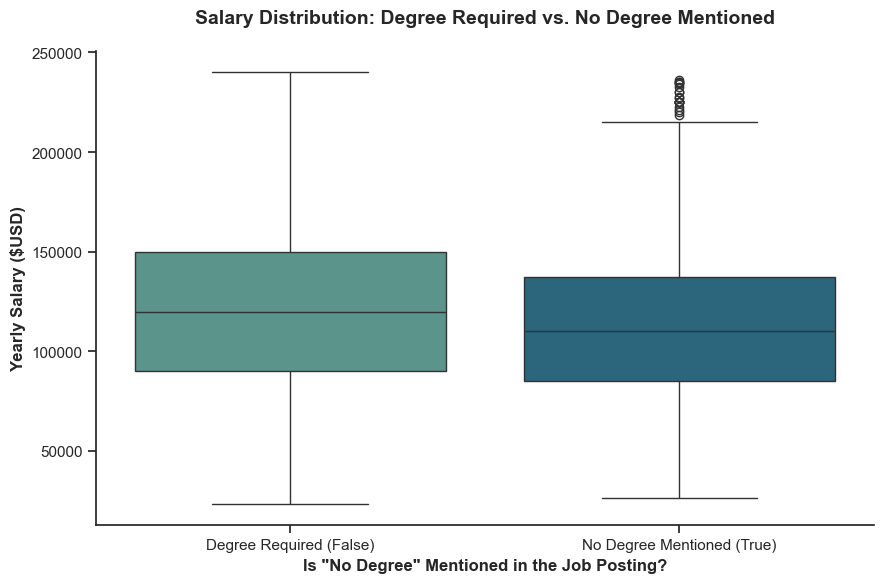

In [ ]:
# Do companies actually pay Data Analysts less if they dont require a degree?
# A boxplot is perfect here because it lets us compare the median and typical salary ranges for both groups side-by-side.
# We use a boxplot to see the distribution of salaries, not just the average
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_salary_cleaned,
    x="job_no_degree_mention",
    y="salary_year_avg",
    palette="crest",
)
sns.despine()

plt.title(
    "Salary Distribution: Degree Required vs. No Degree Mentioned", fontsize=14, pad=15, weight = 'bold'
)
plt.xlabel('Is "No Degree" Mentioned in the Job Posting?', fontsize=12, weight = 'bold')
plt.ylabel("Yearly Salary ($USD)", fontsize=12, weight = 'bold')

# Customizing the x-axis labels for readability
plt.xticks(
    ticks=[0, 1], labels=["Degree Required (False)", "No Degree Mentioned (True)"]
)
plt.tight_layout()
plt.show()

### Insights

Does a company pay you less if they don't require a degree? The data says: not really. For most Data Analyst roles, the average salary is surprisingly similar whether a degree is asked for or not. While the absolute highest-paying jobs still want that piece of paper, strong technical skills and a good portfolio are more than enough to get you a highly competitive salary in today's market.


## Investigate Median Salary VS Skill for Data Analysts


In [9]:
# Explode the clean dataset to analyze skills
df_DA_skills_exploded = df_salary_cleaned.explode("job_skills")

# Calculate Most Popular Skills
df_DA_skills = (
    df_DA_skills_exploded.groupby("job_skills")["salary_year_avg"]
    .agg(["count", "median"])
    .sort_values(by="count", ascending=False)
)
df_DA_skills = df_DA_skills.head(10).sort_values(by="median", ascending=False)

# Calculate Highest Paying Skills (Filtering for skills that appear at least 5 times so we don't get weird 1-job anomalies)
df_DA_top_pay = df_DA_skills_exploded.groupby("job_skills")["salary_year_avg"].agg(
    ["count", "median"]
)
df_DA_top_pay = (
    df_DA_top_pay[df_DA_top_pay["count"] >= 5]
    .sort_values(by="median", ascending=False)
    .head(10)
)

In [10]:
# top pay data skills df
df_DA_US = df_DA_US.explode("job_skills")
df_DA_US[["salary_year_avg", "job_skills"]].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [11]:
# Calculating the Highest Paying Skills.
# Filtering for skills that appear at least 5 times to ensure our median salaries aren't skewed by a single weird job posting.
df_DA_top_pay = (
    df_DA_US.groupby("job_skills")["salary_year_avg"]
    .agg(["count", "median"])
    .sort_values(by="median", ascending=False)
)

df_DA_top_pay = df_DA_top_pay.head(10)

In [12]:
# most popular data skills
df_DA_skills = (
    df_DA_US.groupby("job_skills")["salary_year_avg"]
    .agg(["count", "median"])
    .sort_values(by="count", ascending=False)
)
df_DA_skills = df_DA_skills.head(10).sort_values(by="median", ascending=False)
df_DA_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


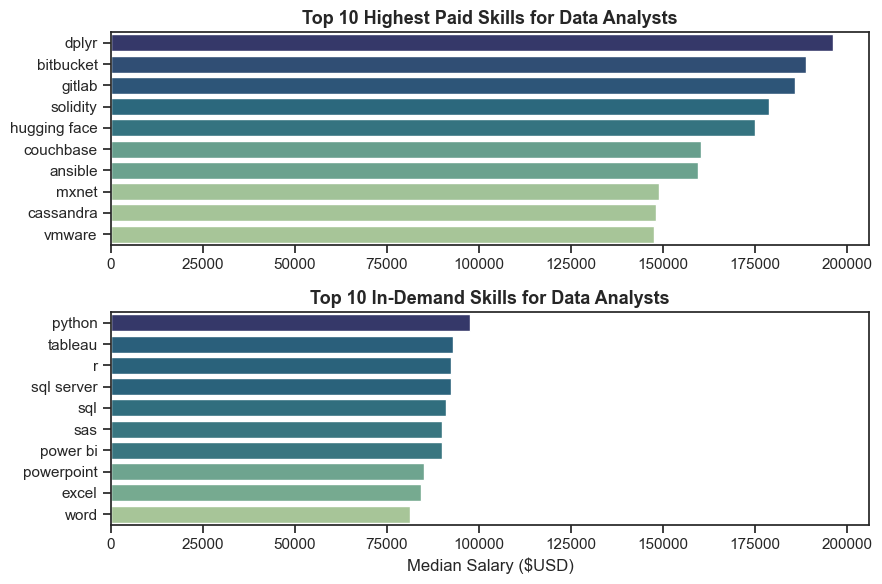

In [50]:
# Generating a stacked plot for The highest-paying skills vs. the most frequently requested skills.
# This helps us clearly see the difference between niche, premium-priced tools and foundational, highly demanded tools.
fig, ax = plt.subplots(2, 1, figsize = (9,6))

sns.set_theme(style="ticks")

sns.barplot(
    data=df_DA_top_pay,
    x="median",
    y=df_DA_top_pay.index,
    ax=ax[0],
    hue="median",
    palette="crest",
    legend=False,
)
# Alternate way
# df_DA_top_pay.plot(kind="barh", y="median", ax=ax[0], legend=False)


ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts", fontsize = 13, weight = 'bold')


sns.barplot(
    data=df_DA_skills,
    x="median",
    y=df_DA_skills.index,
    ax=ax[1],
    hue="median",
    palette="crest",
)

# df_DA_skills[::-1].plot(kind="barh", y="median", ax=ax[1])  # see we used 2 methods to invert the y axis, or reverse the y axis


ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title("Top 10 In-Demand Skills for Data Analysts", fontsize = 13, weight = 'bold')
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary ($USD)")

plt.legend().set_visible(0)  # 2 ways to remove legend
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_6388\1551846508.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


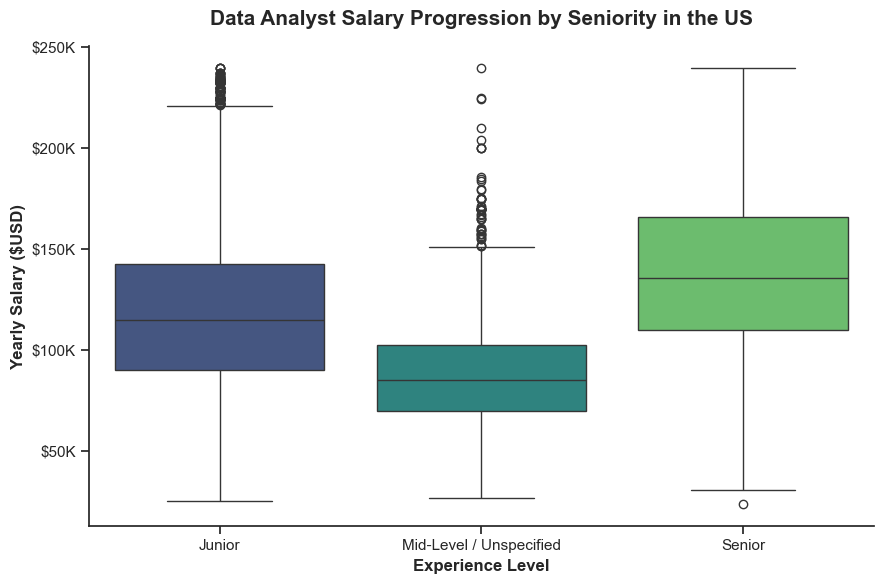

In [53]:
# Using the clean salary dataset (outliers removed)
plt.figure(figsize=(9, 6))

# Plotting the salary distribution across the three seniority levels
sns.boxplot(
    data=df_salary_cleaned,
    x="job_level",
    y="salary_year_avg",
    order=[
        "Junior",
        "Mid-Level / Unspecified",
        "Senior",
    ],  # Forces logical progression left-to-right
    palette="viridis",
)
sns.despine()

# Formatting axes
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))

plt.title("Data Analyst Salary Progression by Seniority in the US", fontsize=15, pad=15, weight = 'bold')
plt.xlabel("Experience Level", fontsize=12, weight = 'bold')
plt.ylabel("Yearly Salary ($USD)", fontsize=12, weight = 'bold')

plt.tight_layout()
plt.show()